In [ ]:
import sys
import os

# Get the root directory (QAOA_mtrix_simulation)
sys.path.insert(0, r'C:\Users\N1259534\OneDrive - Nottingham Trent University\Desktop\Projects\QAOA_simulation_LV\QAOA_mtrix_simulation')
sys.executable


'c:\\Users\\N1259534\\AppData\\Local\\anaconda3\\envs\\qaoa_sim\\python.exe'

In [21]:
import numpy as  np
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt



N =4
np.random.seed(10)
terms = [(np.random.normal(), spin_pair) for spin_pair in combinations(range(N), r=2)]

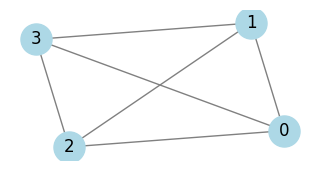

In [24]:

G = nx.Graph()
for wight, (node1, node2) in terms:
    G.add_edge(node1, node2, wight=round(wight, 2))
    
plt.figure(figsize=(3, 1.5))
pos = nx.spring_layout(G)  # Layout for visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500, font_size=12)


plt.show()


In [25]:
# New test


import networkx as nx
from main.QAOA_objective import get_qaoa_objective

# Create graph
#G = nx.karate_club_graph()


# Get objective - ONE LINE!
obj = get_qaoa_objective(G=G, simulator="auto")

# Optimize
from scipy.optimize import minimize
theta0 = np.random.rand(4)  # p=2 layers
result = minimize(obj, theta0, method='COBYLA')




In [38]:
theta = np.random.rand(4)  # 4 parameters for p=2 (2 gammas, 2 betas)
cost_value = obj(theta)
print(f"Objective value: {cost_value}")


Objective value: -3.4592057628529425


In [ ]:
# Still works for non-MaxCut problems
terms = [(1.0, (0,1)), (0.5, (1,2)), (0.3, (0,2))]
obj = get_qaoa_objective(N=3, terms=terms, simulator="fpga")

In [ ]:
simulation_class = main.Base.choose_simulator(name='auto')
sim = simulation_class(N, terms=terms)

In [7]:
sim.get_cost_diagonal()

array([ 0.39433175, -0.60859862, -3.49474551,  0.82867014,  0.42071262,
        2.27889815, -3.50190003,  3.68263151,  3.68263151, -3.50190003,
        2.27889815,  0.42071262,  0.82867014, -3.49474551, -0.60859862,
        0.39433175])

In [8]:
p = 3
gamma, beta = np.random.rand(2, 3)
result = sim.simulate_qaoa(gamma,beta)

In [9]:
sv = sim.get_statevector(result)
sv

array([0.13720186+0.14502526j, 0.09431783+0.12211294j,
       0.04665999-0.1383308j , 0.16514588+0.16112639j,
       0.15497791+0.17550594j, 0.26061719+0.187216j  ,
       0.03410968-0.17167419j, 0.36219128+0.20537478j,
       0.36219128+0.20537478j, 0.03410968-0.17167419j,
       0.26061719+0.187216j  , 0.15497791+0.17550594j,
       0.16514588+0.16112639j, 0.04665999-0.1383308j ,
       0.09431783+0.12211294j, 0.13720186+0.14502526j])

In [10]:
probs = sim.get_probabilities(result)
probs.sum()

np.float64(1.0000000000000002)

In [11]:
prob = sim.get_probabilities(result)
sv2 = sim.get_statevector(result)
print("Using numpy") if np.allclose(sv, sv2) else print("Yohoo, I'm using a memory-economic simulator!")


Using numpy


In [12]:
e = sim.get_expectation(result)
costs_inv = 1/sim.get_cost_diagonal()
e_inv = sim.get_expectation(result, costs=costs_inv)
print("Expectation of C:", e)
print("1/(Expectation of 1/C): ", 1/e_inv)

Expectation of C: 1.5194551853006741
1/(Expectation of 1/C):  1.4973912754030274


In [13]:
overlap = sim.get_overlap(result)
print("Ground state overlap:", overlap)
# Below we test that for positive-valued cost function, the maximum can be achieved 
# by either inverting the values, or negating the values.
costs_abs = np.abs(sim.get_cost_diagonal())
print("Overlap with ground state for absolute cost:", sim.get_overlap(result, costs=costs_abs))
overlap_inv = sim.get_overlap(result, costs=1/costs_abs)
print("Overlap with highest state (inverted costs):", overlap_inv)
overlap_neg = sim.get_overlap(result, costs=-costs_abs)
print("Overlap with highest state (negative):", overlap_neg)
assert overlap_inv == overlap_neg, "You may have values of mixed sign in your cost."

Ground state overlap: 0.06127099876467235
Overlap with ground state for absolute cost: 0.07971335246821881
Overlap with highest state (inverted costs): 0.3467226426138629
Overlap with highest state (negative): 0.3467226426138629
